# Visulization of Attention

In [1]:
import torch
import pandas as pd

device = torch.cuda.is_available()

print(f"GPU is: {device}")
print("cuda" if device else "CPU")

GPU is: True
cuda


In [2]:
from transformers import AutoModelForSequenceClassification, AutoTokenizer
import numpy as np

model_name = "cardiffnlp/twitter-roberta-base-sentiment-latest"
model = AutoModelForSequenceClassification.from_pretrained(model_name, output_attentions=True)
tokenizer = AutoTokenizer.from_pretrained(model_name)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

Some weights of the model checkpoint at cardiffnlp/twitter-roberta-base-sentiment-latest were not used when initializing RobertaForSequenceClassification: ['roberta.pooler.dense.bias', 'roberta.pooler.dense.weight']
- This IS expected if you are initializing RobertaForSequenceClassification from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing RobertaForSequenceClassification from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).


RobertaForSequenceClassification(
  (roberta): RobertaModel(
    (embeddings): RobertaEmbeddings(
      (word_embeddings): Embedding(50265, 768, padding_idx=1)
      (position_embeddings): Embedding(514, 768, padding_idx=1)
      (token_type_embeddings): Embedding(1, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): RobertaEncoder(
      (layer): ModuleList(
        (0-11): 12 x RobertaLayer(
          (attention): RobertaAttention(
            (self): RobertaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): RobertaSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
             

In [ ]:
model.config.output_attentions = True

In [82]:
'''Loading The Datasets'''


pro_sample = pd.read_csv("pro_sample_with_shap.csv")
anti_sample = pd.read_csv("anti_sample_with_shap.csv")
print('Data loaded Succesfully')


Data loaded Succesfully


In [5]:
pro_sample.head()

,Unnamed: 0,date,clean_text_no_stopwords,sentiment_label,sentiment_score,sentiment_label_bert,sentiment_score_bert,robust_senti_label,robust_senti_score,vader_score,...,textblob_label,afinn_score,afinn_label,robust_label,cluster_label_new,word_count,shap_computed,shap_mean_abs,shap_max_abs,shap_top_feature
0,480000,2019-11-17 09:33:25+00:00,another benefit one part fails print well dont...,negative,0.519698,negative,0.851765,Neutral,0.375562,0.3182,...,negative,0.0,neutral,neutral,2.0,11,True,0.051736,0.214305,fails
1,317739,2022-08-16 23:38:01+00:00,spontaneous subarachnoid haemorrhage subarachn...,negative,0.733934,negative,0.691403,Neutral,0.534279,-0.7351,...,negative,-1.0,negative,neutral,0.0,57,True,0.014472,0.139693,quality
2,433344,2018-01-07 09:56:01+00:00,fast would catch fire put 600watt load,negative,0.720536,neutral,0.858063,Very Positive,0.406716,-0.3400,...,positive,-2.0,negative,positive,0.0,7,True,0.088447,0.286125,fire
3,114880,2022-10-05 17:34:30+00:00,health secretary must tackle nhs workforce pay...,negative,0.505479,negative,0.604123,Neutral,0.470170,-0.4404,...,negative,-6.0,negative,neutral,2.0,94,True,0.012266,0.151321,x201cpainful
4,244118,2018-11-06 01:55:53+00:00,seven 8 childrens tonsillectomies unnecessary ...,negative,0.755422,negative,0.968425,Neutral,0.319635,0.4588,...,negative,1.0,positive,neutral,1.0,17,True,0.070545,0.480467,unnecessary


In [6]:
anti_sample.head()

,Unnamed: 0,date,clean_text_no_stopwords,sentiment_label,sentiment_score,sentiment_label_bert,sentiment_score_bert,robust_senti_label,robust_senti_score,vader_score,...,afinn_score,afinn_label,robust_label,cluster_label_new,cluster_label,word_count,shap_computed,shap_mean_abs,shap_max_abs,shap_top_feature
0,943167,2023-01-27 23:28:05+00:00,dr aaron lewis understand many medical freedom...,negative,0.642835,neutral,0.902384,Neutral,0.315207,0.7274,...,5.0,positive,neutral,NaN,NaN,25,True,0.048383,0.286734,sadness
1,259702,2023-04-08 13:36:23+00:00,omg want go rabbit hole easter weekend theres ...,negative,0.672662,neutral,0.818963,Very Negative,0.281637,-0.6096,...,1.0,positive,negative,NaN,2.0,35,True,0.031028,0.179706,omg
2,928892,2023-01-06 22:53:09+00:00,capitol police arrest mother whose daughter sh...,negative,0.660888,negative,0.908682,Neutral,0.410993,-0.9382,...,-10.0,negative,neutral,NaN,NaN,27,True,0.062052,0.342747,murder
3,774824,2022-07-12 04:40:46+00:00,germany stands netherlands takes streets prote...,negative,0.749439,neutral,0.677172,Neutral,0.562751,0.1027,...,-3.0,negative,neutral,NaN,NaN,20,True,0.053673,0.583636,stupidity
4,498747,2021-07-11 08:28:23+00:00,routine blood test 2 years ago doctor told cho...,negative,0.787580,negative,0.891942,Neutral,0.416897,-0.7918,...,0.0,neutral,neutral,NaN,0.0,57,True,0.021631,0.152533,happy


In [84]:
text_pro = pro_sample['clean_text_no_stopwords'].iloc[17]
print(30*"=")
print("Pro_Text-Example:\n", text_pro)
text_anti = anti_sample['clean_text_no_stopwords'].iloc[0]
print(30*"=")
print("Anti_Text-Example:\n", text_anti)

Pro_Text-Example:
 know stopping routine cancer screening jama internal medicine patient page describes benefits harms cancer screening decide may time stop routine screening jamaupdates
Anti_Text-Example:
 dr aaron lewis understand many medical freedom movement feel dr golds behavior share feelings brings nothing sadness watch someone started place moral righteousness lose way


In [85]:
from bertviz import head_view

inputs = tokenizer(
    text_pro, # For pro Example only 
    return_tensors="pt",
    truncation=True,
    max_length=128
).to(device)
with torch.no_grad():
    outputs = model(**inputs)

attentions = outputs.attentions

tokens = tokenizer.convert_ids_to_tokens(inputs['input_ids'][0])
attentions_cpu = [layer_att.cpu() for layer_att in attentions]
head_view(attentions_cpu, tokens)


<IPython.core.display.Javascript object>

In [86]:
inputs = tokenizer(text_pro, return_tensors="pt", truncation=True).to(device)

num_layers = model.config.num_hidden_layers
num_heads = model.config.num_attention_heads

print("Number of layers:", num_layers)
print("Number of attention heads:", num_heads)


with torch.no_grad():
    outputs = model(**inputs)

att = outputs.attentions  # list of layers
# print(att)
print("Layers in attention output:", len(att))

print(f"Shape of First attention: {att[0].shape}")



Number of layers: 12
Number of attention heads: 12
Layers in attention output: 12
Shape of First attention: torch.Size([1, 12, 28, 28])


In [87]:
import numpy as np

for layer in range(num_layers):
    for head in range(num_heads):
        att_matrix = att[layer][0][head].cpu().numpy()
        mean_attention = att_matrix.mean()
        print(f"Layer {layer}, Head {head}: mean {mean_attention:.4f}")


Layer 0, Head 0: mean 0.0357
Layer 0, Head 1: mean 0.0357
Layer 0, Head 2: mean 0.0357
Layer 0, Head 3: mean 0.0357
Layer 0, Head 4: mean 0.0357
Layer 0, Head 5: mean 0.0357
Layer 0, Head 6: mean 0.0357
Layer 0, Head 7: mean 0.0357
Layer 0, Head 8: mean 0.0357
Layer 0, Head 9: mean 0.0357
Layer 0, Head 10: mean 0.0357
Layer 0, Head 11: mean 0.0357
Layer 1, Head 0: mean 0.0357
Layer 1, Head 1: mean 0.0357
Layer 1, Head 2: mean 0.0357
Layer 1, Head 3: mean 0.0357
Layer 1, Head 4: mean 0.0357
Layer 1, Head 5: mean 0.0357
Layer 1, Head 6: mean 0.0357
Layer 1, Head 7: mean 0.0357
Layer 1, Head 8: mean 0.0357
Layer 1, Head 9: mean 0.0357
Layer 1, Head 10: mean 0.0357
Layer 1, Head 11: mean 0.0357
Layer 2, Head 0: mean 0.0357
Layer 2, Head 1: mean 0.0357
Layer 2, Head 2: mean 0.0357
Layer 2, Head 3: mean 0.0357
Layer 2, Head 4: mean 0.0357
Layer 2, Head 5: mean 0.0357
Layer 2, Head 6: mean 0.0357
Layer 2, Head 7: mean 0.0357
Layer 2, Head 8: mean 0.0357
Layer 2, Head 9: mean 0.0357
Layer 2, H

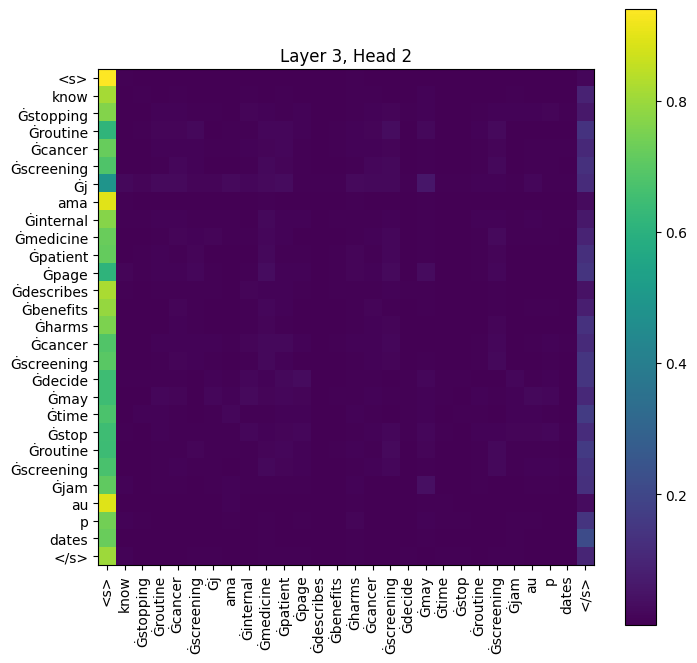

(28, 28)


In [88]:
import matplotlib.pyplot as plt
layer = 3
head = 2
att_matrix = att[layer][0][head].cpu().numpy()


tokens = tokenizer.convert_ids_to_tokens(inputs['input_ids'][0])

plt.figure(figsize=(8, 8))
plt.imshow(att_matrix)
plt.xticks(range(len(tokens)), tokens, rotation=90)
plt.yticks(range(len(tokens)), tokens)
plt.title(f"Layer {layer}, Head {head}")
plt.colorbar()
plt.show()

print(att_matrix.shape)

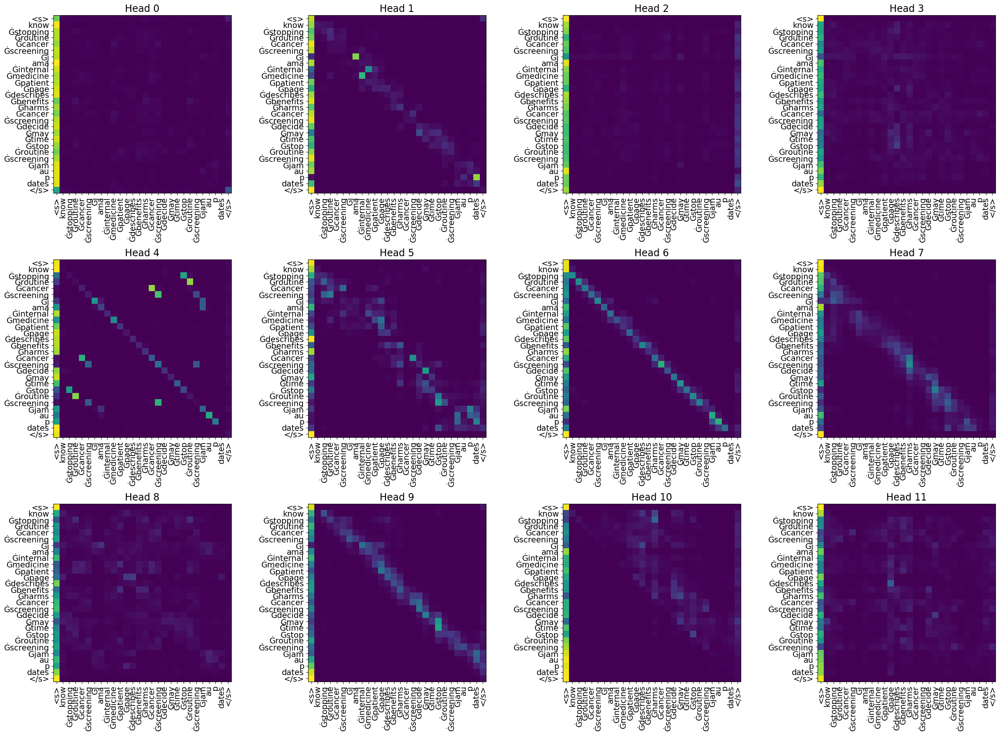

In [89]:
tokens = tokenizer.convert_ids_to_tokens(inputs['input_ids'][0])

fig, axes = plt.subplots(3, 4, figsize=(25, 18))

for head in range(num_heads):
    ax = axes[head // 4, head % 4]
    att_matrix = att[layer][0][head].cpu().numpy()
    im = ax.imshow(att_matrix)

    # Add tokens
    ax.set_xticks(range(len(tokens)))
    ax.set_yticks(range(len(tokens)))
    ax.set_xticklabels(tokens, rotation=90, fontsize=14)
    ax.set_yticklabels(tokens, fontsize=14)

    ax.set_title(f"Head {head}", fontsize=17)

plt.tight_layout()
plt.show()


Layer 9, Head 4 has the most strong connections: 56


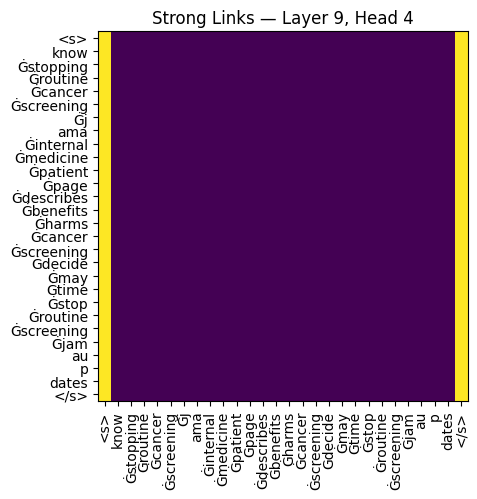

In [90]:
num_layers = model.config.num_hidden_layers
num_heads = model.config.num_attention_heads

best_layer, best_head = None, None
max_links = 0

for layer in range(num_layers):
    for head in range(num_heads):
        att_matrix = att[layer][0][head].cpu().numpy()
        strong_links = (att_matrix > 0.3).sum()
        if strong_links > max_links:
            max_links = strong_links
            best_layer, best_head = layer, head

print(f"Layer {best_layer}, Head {best_head} has the most strong connections: {max_links}")
att_matrix = att[best_layer][0][best_head].cpu().numpy()
mask = att_matrix > 0.3

plt.imshow(mask)
plt.xticks(range(len(tokens)), tokens, rotation=90)
plt.yticks(range(len(tokens)), tokens)
plt.title(f"Strong Links — Layer {best_layer}, Head {best_head}")
plt.show()


# STAT

In [93]:
# Example: mean attention per head across multiple texts
mean_att_pro = np.zeros((num_layers, num_heads))
mean_att_anti = np.zeros((num_layers, num_heads))

for text in pro_sample['clean_text_no_stopwords']:
    inputs = tokenizer(text, return_tensors="pt", truncation=True, max_length=128).to(device)
    with torch.no_grad():
        outputs = model(**inputs)
    att = outputs.attentions
    for layer in range(num_layers):
        for head in range(num_heads):
            mean_att_pro[layer, head] += att[layer][0][head].cpu().numpy().mean()

mean_att_pro /= len(pro_sample)


In [95]:
mean_att_anti = np.zeros((num_layers, num_heads))

for text in anti_sample['clean_text_no_stopwords']:
    inputs = tokenizer(text, return_tensors="pt", truncation=True, max_length=128).to(device)
    with torch.no_grad():
        outputs = model(**inputs)
    att = outputs.attentions
    for layer in range(num_layers):
        for head in range(num_heads):
            mean_att_pro[layer, head] += att[layer][0][head].cpu().numpy().mean()

mean_att_anti /= len(anti_sample)


# Anti-Science

In [16]:
from bertviz import head_view

inputs = tokenizer(
    text_anti, # For anti Example only 
    return_tensors="pt",
    truncation=True,
    max_length=128
).to(device)
with torch.no_grad():
    outputs = model(**inputs)

attentions = outputs.attentions

tokens = tokenizer.convert_ids_to_tokens(inputs['input_ids'][0])
attentions_cpu = [layer_att.cpu() for layer_att in attentions]
head_view(attentions_cpu, tokens)

<IPython.core.display.Javascript object>

In [74]:
inputs_anti = tokenizer(text_anti, return_tensors="pt", truncation=True).to(device)

num_layers = model.config.num_hidden_layers
num_heads = model.config.num_attention_heads

print("Number of layers:", num_layers)
print("Number of attention heads:", num_heads)


with torch.no_grad():
    outputs_anti = model(**inputs_anti)

att_anti = outputs_anti.attentions  # list of layers
# print(att)
print("Layers in attention output:", len(att_anti))

print(f"Shape of First attention: {att_anti[0].shape}")



Number of layers: 12
Number of attention heads: 12
Layers in attention output: 12
Shape of First attention: torch.Size([1, 12, 31, 31])


In [75]:
import numpy as np

for layer in range(num_layers):
    for head in range(num_heads):
        att_matrix_anti = att_anti[layer][0][head].cpu().numpy()
        mean_attention_anti = att_matrix_anti.mean()
        print(f"Layer {layer}, Head {head}: mean {mean_attention_anti:.4f}")


Layer 0, Head 0: mean 0.0323
Layer 0, Head 1: mean 0.0323
Layer 0, Head 2: mean 0.0323
Layer 0, Head 3: mean 0.0323
Layer 0, Head 4: mean 0.0323
Layer 0, Head 5: mean 0.0323
Layer 0, Head 6: mean 0.0323
Layer 0, Head 7: mean 0.0323
Layer 0, Head 8: mean 0.0323
Layer 0, Head 9: mean 0.0323
Layer 0, Head 10: mean 0.0323
Layer 0, Head 11: mean 0.0323
Layer 1, Head 0: mean 0.0323
Layer 1, Head 1: mean 0.0323
Layer 1, Head 2: mean 0.0323
Layer 1, Head 3: mean 0.0323
Layer 1, Head 4: mean 0.0323
Layer 1, Head 5: mean 0.0323
Layer 1, Head 6: mean 0.0323
Layer 1, Head 7: mean 0.0323
Layer 1, Head 8: mean 0.0323
Layer 1, Head 9: mean 0.0323
Layer 1, Head 10: mean 0.0323
Layer 1, Head 11: mean 0.0323
Layer 2, Head 0: mean 0.0323
Layer 2, Head 1: mean 0.0323
Layer 2, Head 2: mean 0.0323
Layer 2, Head 3: mean 0.0323
Layer 2, Head 4: mean 0.0323
Layer 2, Head 5: mean 0.0323
Layer 2, Head 6: mean 0.0323
Layer 2, Head 7: mean 0.0323
Layer 2, Head 8: mean 0.0323
Layer 2, Head 9: mean 0.0323
Layer 2, H

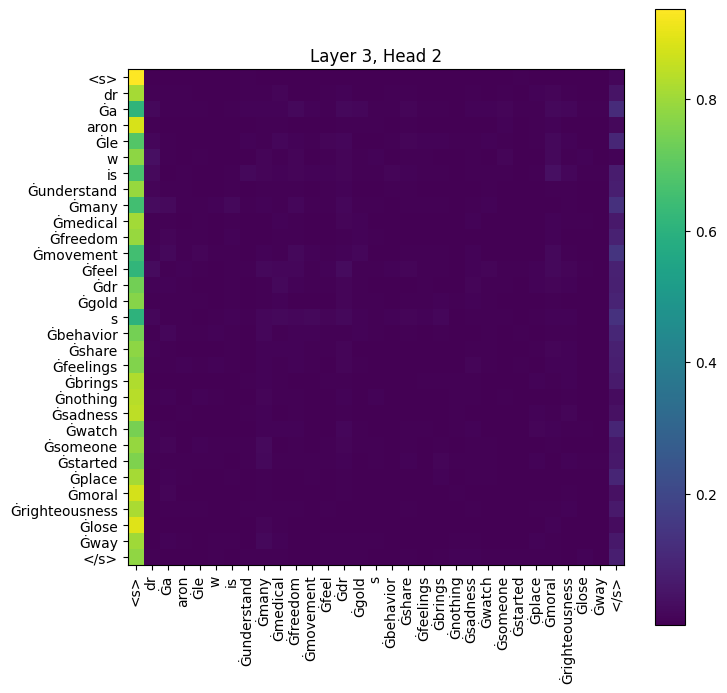

(31, 31)


In [77]:
import matplotlib.pyplot as plt
layer = 3
head = 2
att_matrix_anti = att[layer][0][head].cpu().numpy()


tokens_anti = tokenizer.convert_ids_to_tokens(inputs['input_ids'][0])

plt.figure(figsize=(8, 8))
plt.imshow(att_matrix_anti)
plt.xticks(range(len(tokens_anti)), tokens_anti, rotation=90)
plt.yticks(range(len(tokens_anti)), tokens_anti)
plt.title(f"Layer {layer}, Head {head}")
plt.colorbar()
plt.show()

print(att_matrix_anti.shape)

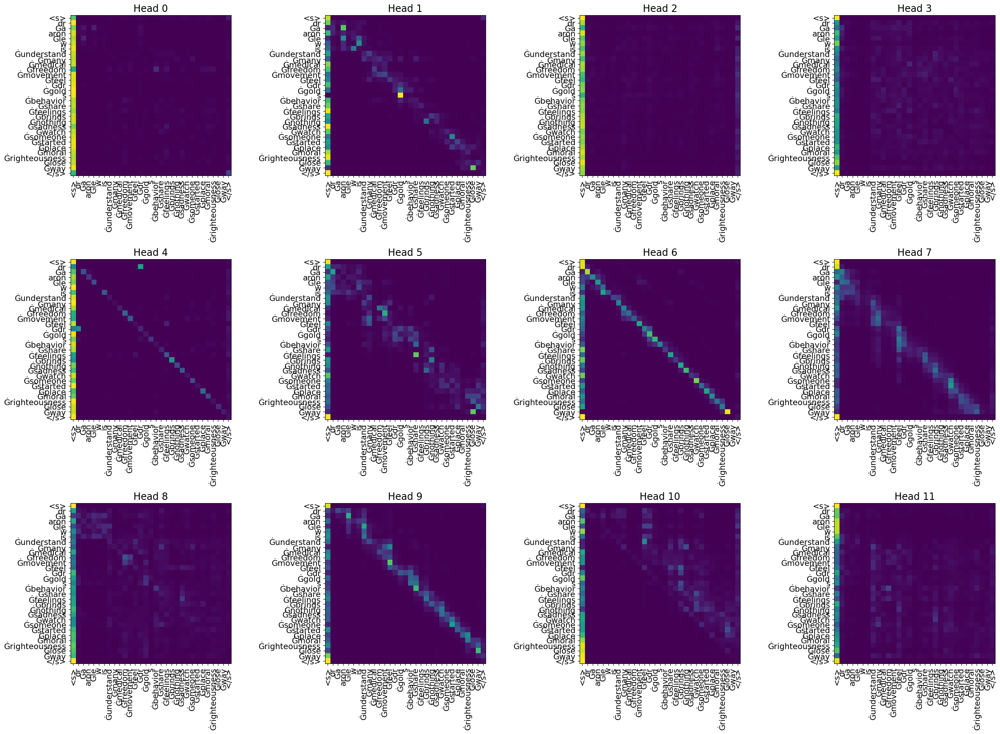

In [78]:
tokens_anti = tokenizer.convert_ids_to_tokens(inputs_anti['input_ids'][0])

fig, axes = plt.subplots(3, 4, figsize=(25, 18))

for head in range(num_heads):
    ax = axes[head // 4, head % 4]
    att_matrix_anti = att[layer][0][head].cpu().numpy()
    im_anti = ax.imshow(att_matrix_anti)

    # Add tokens
    ax.set_xticks(range(len(tokens_anti)))
    ax.set_yticks(range(len(tokens_anti)))
    ax.set_xticklabels(tokens_anti, rotation=90, fontsize=14)
    ax.set_yticklabels(tokens_anti, fontsize=14)

    ax.set_title(f"Head {head}", fontsize=17)

plt.tight_layout()
plt.show()


Layer 9, Head 4 has the most strong connections: 62


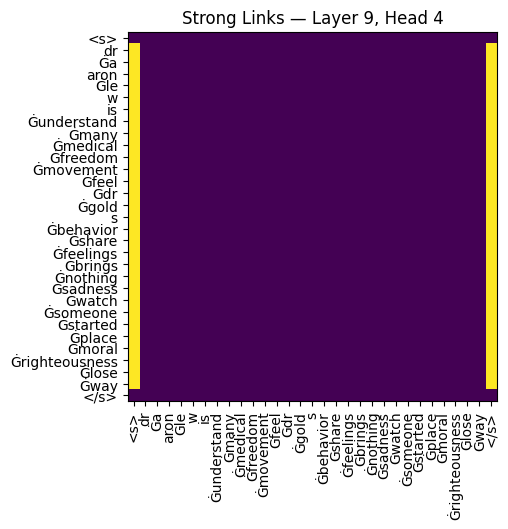

In [79]:
num_layers = model.config.num_hidden_layers
num_heads = model.config.num_attention_heads

best_layer, best_head = None, None
max_links = 0

for layer in range(num_layers):
    for head in range(num_heads):
        att_matrix_anti = att[layer][0][head].cpu().numpy()
        strong_links = (att_matrix_anti > 0.3).sum()
        if strong_links > max_links:
            max_links = strong_links
            best_layer, best_head = layer, head

print(f"Layer {best_layer}, Head {best_head} has the most strong connections: {max_links}")
att_matrix = att[best_layer][0][best_head].cpu().numpy()
mask_anti = att_matrix_anti > 0.3

plt.imshow(mask_anti)
plt.xticks(range(len(tokens_anti)), tokens_anti, rotation=90)
plt.yticks(range(len(tokens_anti)), tokens_anti)
plt.title(f"Strong Links — Layer {best_layer}, Head {best_head}")
plt.show()


# Model-Level-Anti

In [109]:
from bertviz import model_view

# Pick a representative sample, e.g., first Pro sample
text = pro_sample['clean_text_no_stopwords'].iloc[0]

# Tokenize and prepare input
inputs = tokenizer(
    text,
    return_tensors="pt",
    truncation=True,
    max_length=128
).to(device)

# Forward pass
with torch.no_grad():
    outputs = model(**inputs)

# Extract attentions
attentions = outputs.attentions
tokens = tokenizer.convert_ids_to_tokens(inputs['input_ids'][0])

# Move attentions to CPU
attentions_cpu = [layer.cpu() for layer in attentions]

# Model-level visualization
model_view(attentions_cpu, tokens)


<IPython.core.display.Javascript object>

In [100]:
from bertviz import model_view

# Pick a representative sample, e.g., first anti sample
text = anti_sample['clean_text_no_stopwords'].iloc[0]

inputs = tokenizer(
    text,
    return_tensors="pt",
    truncation=True,
    max_length=128
).to(device)

with torch.no_grad():
    outputs = model(**inputs)

attentions = outputs.attentions
tokens = tokenizer.convert_ids_to_tokens(inputs['input_ids'][0])

# Move attentions to CPU
attentions_cpu = [layer.cpu() for layer in attentions]

# Model-level visualization
model_view(attentions_cpu, tokens)


<IPython.core.display.Javascript object>